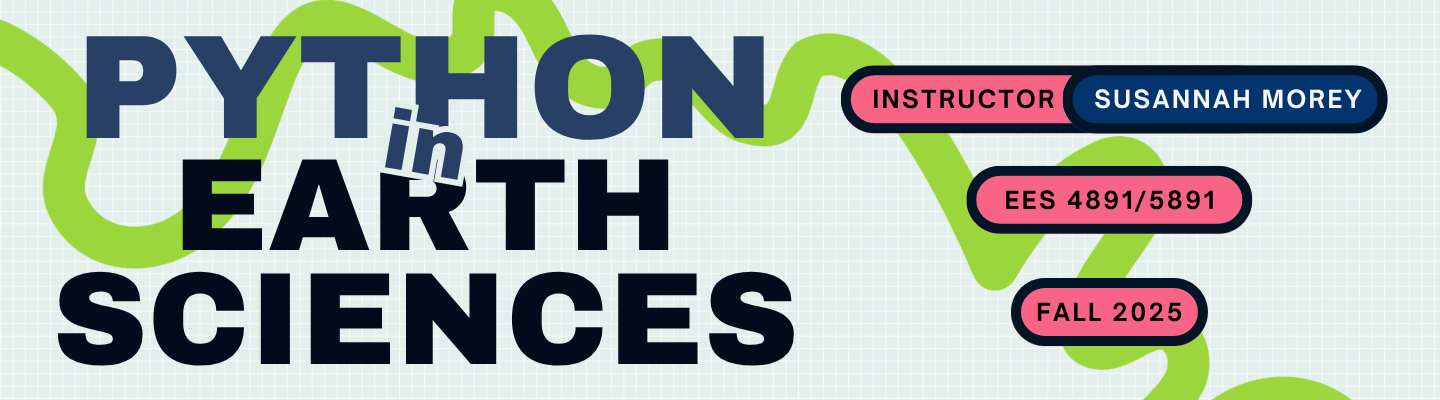

# Introduction to NumPy and arrays

### Learning Goals

- Import numpy
- Create numpy array variables using `array`, `zeros`, `ones`, `arange`, and `linspace`
- Use slicing to index values in an array
- Perform operations on arrays


## Where we left off....

<div class="alert alert-warning"> 
<b><u> From Lecture Notebook 8: Exercise 2</b></u> <br>

#### <u>Part 3</u> : 
##### Write a count-controlled nested `for` loop to model erosion at four different Appalachian peaks.
- use nested `for` loops to model **4000 years** of erosion for each peak
- the outer loop should iterate through each mountain peak
    - print the peak name, initial elevation, and erosion rate, rounding your print out to 2 decimal place
- the inner loop should model erosion year by year using **each peak's specific erosion rates**
    - print the final elevation and total erosion, rounding your print out to 1 decimal place
- after both loops finish: determine which peak is now the tallest and which peak lost the most elevation.

<span style="color: blue;"> BONUS CHALLENGE <span><br>
- add an `if` statement that prints which peaks have "fast erosion" (erosion rate >4e-5 m/yr) when you start modeling each peak

In [2]:
# [peak_name, initial_elevation_in_meters, erosion_rate_m_per_year]
appalachian_peaks = [
    ['Mount Mitchell', 2037, 2.7e-05],       # Granite - slower erosion
    ['Mount Washington', 1916, 3.1e-05],     # Mixed rock - moderate erosion  
    ['Grandfather Mountain', 1800, 4.2e-05], # Quartzite - faster erosion
    ['Mount Rogers', 1746, 3.8e-05]          # Gneiss - moderate-fast erosion
]

### One Solution using nested for loops and lists

In [3]:
years = 4000                                                                # define time
final_elevation = []                                                        # define empty final elevation list
total_erosion = []                                                          # define emtpy total erosion list
#final_data = []                                                             # OR you could create ONE list and aim to have internal lists with final elevation and total erosion


# Creat nested for loop
for i in range(len(appalachian_peaks)):                                     # Outer loop: cycles through each peak (should do it 4 times)
    # Set up variables for easy access
    peak_name = appalachian_peaks[i][0]                                     # peak name variable
    initial_elevation = appalachian_peaks[i][1]                             # initial elevation variable.                                                               NOTE: Comment out if you replace this (see below)
    current_elevation = initial_elevation                                   # dummy variable to keep initial elevation stored in it's own variable.                     NOTE: comment out if you replace this (see below)
    #current_elevation = appalachian_peaks[i][1]                             # or instead of having the 2 lines above, you can just grab current elevation like this.   NOTE: to access initial elevation, you need to then grab the index of it from appalachian_peaks
    erosion_rate = appalachian_peaks[i][2]                                  # erosion rate variable

    # Print Statements
    print(f"{peak_name}:")                                                  # print peak name
    print(f"  Initial elevation: {initial_elevation:.6f} m")                # print initial elevation
    if erosion_rate > 4e-5:
        print(f"  Erosion rate: {erosion_rate:.6f} m/yr - That's fast!")    # print erosion rate
    else:
        print(f"  Erosion rate: {erosion_rate:.6f} m/yr")                   # print erosion rate

    for year in range(years):                                               # inner loop: cycles through each year (should do it the # of times of years variable, 4000 in our case) NOTE: I've just used "years". This will automatically set up range(0,4000)
        current_elevation -= erosion_rate                                   # actual calculation that lowers the elevation by the erosion rate

    erosion = initial_elevation - current_elevation                         # calculation of total erosion (initial - current)
    print(f"  Total erosion: {erosion:.1f} m")                              # print total erosion
    print(f"  Final elevation: {current_elevation:.1f} m")                  # print final elevation. NOTE: only prints the LAST iteration of the inner for loop

    # Update our lists of final elevation and total erosion
    final_elevation.append(current_elevation)                               # add last iteration of inner loop to final elevation list
    total_erosion.append(erosion)                                           # add calculated total erosion to total erosion list
    #final_data.append([peak_name, current_elevation, total_erosion])        # or if you wanted to do it in one list (and have it set up outside your for loop) AND you wanted to include peak name so it's clear what values belong to which mountain

# Analysis of data to figure out tallest mountain and most erosion
max_elevation = max(final_elevation)                                        # calculation of maximum elevation, using list
max_erosion = max(total_erosion)                                            # calculation of maximum erosion, using list

# if you have separate lists:
max_elevation = max(final_elevation)                                        # find which peak is the max
max_elev_index = final_elevation.index(max_elevation)                       # grab the index of the maximum elevation value
max_elev_peak = appalachian_peaks[max_elev_index][0]                        # grab the peak name from our original list using the index grabbed previously. We know that it's stored in the 0th index in the inner list.

# Find which peak had the most erosion
max_erosion = max(total_erosion)                                            # find which peak had the most erosion
max_erosion_index = total_erosion.index(max_erosion)                        # grab the index of that max erosion value
max_eroded_peak = appalachian_peaks[max_erosion_index][0]                   # grab the peak name from our original list using the index grabbed previously. We know that it's stored in the 0th index in the inner list.

# print statements
print(f"Tallest remaining peak: {max_elev_peak} ({max_elevation:.1f} m)")   # print the tallest peak
print(f"Most eroded peak: {max_eroded_peak} (lost {max_erosion:.1f} m)")    # print the peak with the most erosion

# if you have it all in one list (i.e., you used final_data at the very beginning and then commented out/in the appropriate lines
# for peak in final_data:                                                   
#     if peak[1] == tallest_elevation:
#         print(f"Tallest remaining peak: {peak[0]} at {max_elevation:.1f} m")
#     if peak[2] == max_erosion:
#         print(f"Most eroded peak: {peak[0]} (lost {max_erosion:.1f} m)")

Mount Mitchell:
  Initial elevation: 2037.000000 m
  Erosion rate: 0.000027 m/yr
  Total erosion: 0.1 m
  Final elevation: 2036.9 m
Mount Washington:
  Initial elevation: 1916.000000 m
  Erosion rate: 0.000031 m/yr
  Total erosion: 0.1 m
  Final elevation: 1915.9 m
Grandfather Mountain:
  Initial elevation: 1800.000000 m
  Erosion rate: 0.000042 m/yr - That's fast!
  Total erosion: 0.2 m
  Final elevation: 1799.8 m
Mount Rogers:
  Initial elevation: 1746.000000 m
  Erosion rate: 0.000038 m/yr
  Total erosion: 0.2 m
  Final elevation: 1745.8 m
Tallest remaining peak: Mount Mitchell (2036.9 m)
Most eroded peak: Grandfather Mountain (lost 0.2 m)


## Why was this terrible?
- 50+ lines of code
- Nested loops (4 peaks × 4000 years = 16,000 iterations!)
- Manual list management
- Index tracking and potential errors
- Verbose variable assignments
## There's an easier way!! Use NumPy!!

In [4]:
import numpy as np

# Convert data to NumPy arrays
peak_names = np.array(['Mount Mitchell', 'Mount Washington', 'Grandfather Mountain', 'Mount Rogers'])
initial_elevations = np.array([2037, 1916, 1800, 1746])
erosion_rates = np.array([2.7e-05, 3.1e-05, 4.2e-05, 3.8e-05])

# Calculate 4000 years of erosion in ONE operation
years = 4000
final_elevations = initial_elevations - (erosion_rates * years)
total_erosion = erosion_rates * years

# Analysis in two lines
tallest_peak = peak_names[np.argmax(final_elevations)]
most_eroded_peak = peak_names[np.argmax(total_erosion)]

print(f"Final elevations: {final_elevations}")
print(f"Tallest remaining: {tallest_peak}")
print(f"Most eroded: {most_eroded_peak}")

Final elevations: [2036.892 1915.876 1799.832 1745.848]
Tallest remaining: Mount Mitchell
Most eroded: Grandfather Mountain


## Why is this better?
- **Compare**: 50+ lines vs. 8 lines
- **Performance**: 16,000 loop iterations vs. instant vectorized operations
- **Readability**: Clear, mathematical expressions
- **Error-prone vs. robust**: No index management needed


#### **Python lists and dictionaries are excellent, general-purpose containers.** Remember that they can contain elements of a variety of types, and they are quite fast when used to perform individual operations on a handful of elements.

#### **NumPy shines when there are large quantities of “homogeneous” (same-type) data to be processed.**

## What is NumPy?

- NumPy [(https://numpy.org/)](https://numpy.org/) is a Python package for scientific computing
- Provides an **array** data type for multi-dimensional arrays
- Provides a host of other functions and capabilities
- Free and open source

## Installing and importing NumPy

NumPy is already installed on our class JupyterHub. If you are using your own computer rather than the hub, you will need to install it. An easy way to do this is to install the [Anaconda Distribution](https://www.anaconda.com/data-science-platform).

Here's a common way to import and test NumPy:

```
import numpy as np

print("Pi is", np.pi)
```

In [5]:
import numpy as np
print("Pi is", np.pi)

Pi is 3.141592653589793


## What is an array?
In computer programming, an **array** is a structure for storing and retrieving data. Numpy uses `ndarray`s, which are similar to Python lists, but with some important differences:
- all objects in an `ndarray` have the same data type
    - default is `float`, but you can change this 
- an `ndarray` can have multiple dimensions (that's the 'n' in 'nd')
    - similar to nested lists, but with more flexibility
- mathematical operations are applied to *all* elements of the array at once.

We often talk about an array as if it were a grid in space, with each cell storing one element of the data. 

For instance, if each element of the data were a number, we might visualize a “one-dimensional” array like a list:<br>
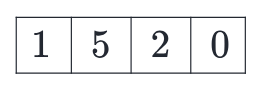<br>
A two-dimensional array would be like a table:<br>
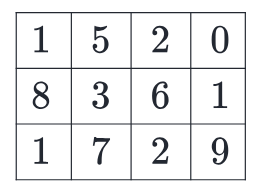

A three-dimensional array would be like a set of tables, perhaps stacked as though they were printed on separate pages. 

#### Some additional rules for arrays:
- All elements of the array must be of the same type of data.
- Once created, the total size of the array can’t change.
- The shape must be “rectangular”, not “jagged”; e.g., each row of a two-dimensional array must have the same number of columns.


## Creating Arrays

Let's make arrays out of those numbers. To make an array, use the `np.array` method.

To make a one-dimensional array, we can do:

In [14]:
test_1D = np.array([1, 5, 2, 0])
print(test_1D)
print(type(test_1D))

type(test_1D)
print("Number of dimensions:", test_1D.ndim)
print("Shape of the array:", test_1D.shape)

[1 5 2 0]
<class 'numpy.ndarray'>
Number of dimensions: 1
Shape of the array: (4,)


To make a two-dimensional array, we can do:

In [13]:
test_2D = np.array([[1, 5, 2, 0],[1, 7, 2, 9]])
print(test_2D)
print(type(test_2D))

type(test_2D)
print("Number of dimensions:", test_2D.ndim)
print("Shape of the array:", test_2D.shape)

[[1 5 2 0]
 [1 7 2 9]]
<class 'numpy.ndarray'>
Number of dimensions: 2
Shape of the array: (2, 4)


### Other Useful ways to create arrays:

| what to write | what it does | example code | example output |
|:-----:|:-------:|:-------:|:-----:|
|`np.zeros()` | creates an array of zeros | `np.zeros(5)` | array([0., 0., 0., 0., 0.]) |
|`np.ones()` | creates an array of ones | `np.ones(5)` | array([1., 1., 1., 1., 1.]) |
|`np.empty()` | creates an empty array with "trash" values | `np.zeros(5)` | array([0., 0., 0., 0., 0.]) |
|`np.arange()` | creates an array of evenly spaced<br> values within a specified interval | `np.arange(0,10,2)` | array([0, 2, 10, 6, 8]) |
|`np.linspace()` | creates an array that is a sequence <br> of evenly spaced numbers over a specified interval | `np.linspace(0,1,5)` | array([0., 0.25, 0.5, 0.75, 1.]) |
|`np.logspace()` | creates an array that is a sequence <br> of evenly spaced numbers over a specified interval in log space| `np.linspace(0,1,5)` | array([ 1., 1.77827941, 3.16227766, 5.62341325, 10.]) |

<div class="alert alert-info"> 

#### Setup your Week 6 Notebook
    
<b><u> Exercise 1</b></u> <br>

1. **You're setting up a network to monitor soil temperatures at 15 different locations around a field site. Before you start collecting data, you need to create an array to store the initial temperature readings (all starting at 0°C).**
    - Create an array of 15 zeros to represent initial temperature readings
    - Print the array and check its length to verify you have 15 monitoring points
2. **You're planning to collect water samples in the ocean at regular depth intervals. You want to sample every 50 meters starting from the surface (0m) down to 500 meters deep.**
    - Create an array of sampling depths from 0 to 500 meters in 50-meter intervals
    - Print the array to see your sampling plan
    - How many samples will you collect? (Print the length of the array)
3. **You're studying how elevation changes along a 10-kilometer transect across a mountain range. You want to take exactly 21 elevation measurements evenly spaced from the start (0 km) to the end (10 km) of your transect.**
    - Create an array of 21 evenly-spaced distances from 0 to 10 kilometers
    - Print the array to see where you'll take measurements
    - What's the spacing between measurement points?
        - (Hint: look at the difference between the first two values)

## Indexing Arrays

Arrays can be indexed using an extended slicing syntax, similar to what we did with lists.

#### Basic Indexing
We can do basic indexing the same way we did it for lists. Just remember that we use zero indexing! For example:

In [ ]:
# Create a sample array
elevations = np.array([1200, 1350, 1500, 1650, 1800])

# Access individual elements (remember: Python starts counting at 0!)
print(elevations[0])    # First element: 1200
print(elevations[2])    # Third element: 1500  
print(elevations[-1])   # Last element: 1800
print(elevations[-2])   # Second-to-last: 1650

#### Slicing
We can also slice the same way we did with lists. This is super handy.

In [ ]:
# Get a range of values using [start:stop]
print(elevations[1:4])   # Elements 1, 2, 3 (NOT 4): [1350 1500 1650]
print(elevations[:3])    # First 3 elements: [1200 1350 1500]
print(elevations[2:])    # From element 2 to end: [1500 1650 1800]
print(elevations[::2])   # Every 2nd element: [1200 1500 1800]

<div class="alert alert-info"> 
    
<b><u> Exercise 2</b></u> <br>

1. **Using your ocean depth array from before, use indexing or slicing to answer the following questions.**
   - What is the shallowest sampling depth?
   - What is the depest sampling depth?
   - You want to analyze just the "shallow" samples (first 4 depths). Get just those values.
   - You want to analyze just the "deep" samples (depths 300m and below). Get those values.
   - For quality control, show every other sampling depth (skip every 2nd one)
2. **Using your mountain transect distance array, using indexing or slicing to answer the following questions.**
    - At what distance will you take your 10th measurement?
    - What are the distances for measurements 15, 16, and 17?
    - You want to focus on the "middle" section of your transect (measurements 6 thorugh 15). Get those distances.
    - For a preliminary analysis, you only want every 5th measurement point. Get those distances.
    - What is the distance of your second-to-last measurement?

## Operations on arrays: array and float/int

If you perform an arithmetic operation between an `ndarray` and a `float` or `int`, the operation is performed on each item in the array, and a new array is produced. Example:

```
n = 2
a = np.array([1, 2, 3, 4, 5])
b = a ** n
print(b)
print(type(b))
```

What happens if you use `+`, `-`, `*`, or `/` instead?

<div class="alert alert-info"> 
    
<b><u> Exercise 3</b></u> <br>

1. **Using your temperature array from before, first, do the following operations**:
    - Add 15 $^\circ$C to all stations at once.
    - Print your new temperature station data.
    - What happens if you use `temperatures + 10` vs `temperatures * 1.5`?
2. **Using your depth array from before, you realize that your depth measurements are in meters but you need them in feet for a US-based research project**:
    - Convert all depths to feet (1 meter = 3.28 ft)
    - Print your new depths.
    - Add a safety margin of 10 meters to each depth
    - Print your new depths.
3. **Your transect distances are in kilometers, but you need them in meters for detailed GPS coordinates**
    - Convert all distances to meters
    - Print the first 5.
    - Convert all distances to miles. (1 km = 0.62 miles)
    - Print the last 5.